# 3CRV Token Holder Network — Centrality Analysis

Build a directed transfer graph of Curve 3pool LP token (3CRV) holders and apply centrality measures. The address book classifies addresses as **EOA** (externally owned account) or **contract** (smart contract); addresses not in the book are assumed to be EOAs (small wallets).

**Sections:**
1. Load data & build the transfer graph
2. Classify nodes (EOA vs Contract)
3. Full-network centrality analysis
4. EOA-only subgraph centrality
5. Contract-only subgraph centrality
6. Comparison across segments

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import json

## 1. Load Data & Build Transfer Graph

In [2]:
# Load LP events and address book
df = pd.read_parquet('data/Curve/3CRV_lpevents.parquet')
with open('data/Curve/address_book.json') as f:
    address_book = json.load(f)  # {address: "eoa" | "contract"}

ZERO = '0x0000000000000000000000000000000000000000'

# Use only transfer events (exclude mint/burn which involve the zero address)
transfers = df[df['category'] == 'transfer'].copy()
print(f"Total events: {len(df):,}")
print(f"Transfer events: {len(transfers):,}")
print(f"Address book entries: {len(address_book):,}")

Total events: 1,103,449
Transfer events: 512,785
Address book entries: 21,837


In [3]:
# Build weighted directed graph: edge weight = total 3CRV transferred
edge_weights = (
    transfers.groupby(['from_address', 'to_address'])['lp_amount']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'total_amount', 'count': 'num_transfers'})
    .reset_index()
)

G_full = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G_full.add_edge(
        row['from_address'], row['to_address'],
        weight=row['total_amount'],
        count=row['num_transfers'],
    )

print(f"Full transfer graph: {G_full.number_of_nodes():,} nodes, {G_full.number_of_edges():,} edges")

Full transfer graph: 29,958 nodes, 73,626 edges


In [4]:
# Define labels for major addresses (from 3CRV_network notebook)
KNOWN_LABELS = {
    '0xbfcf63294ad7105dea65aa58f8ae5be2d9d0952a': 'Curve 3pool\nGauge',
    '0xe74b28c2eae8679e3ccc3a94d5d0de83ccb84705': 'Wintermute\nExploiter',
    '0xed279fdd11ca84beef15af5d39bb4d4bee23f0ca': 'Curve\nLUSD3CRV-f Pool',
    '0x1402c1caa002354fc2c4a4cd2b4045a5b9625ef3': 'Gro Protocol\n3CRV Vault',
    '0xa464e6dcda8ac41e03616f95f4bc98a13b8922dc': 'Curve\nFee Distributor',
    '0x5a6a4d54456819380173272a5e8e9b9904bdf41b': 'Curve\nMIM-3LP3CRV-f',
    '0xc5bddf9843308380375a611c18b50fb9341f502a': 'Yearn\nyveCRV-DAO',
    '0x4f062658eaaf2c1ccf8c8e36d6824cdf41167956': 'Curve\nGUSD Pool',
}

def short_label(addr):
    """Return label for known addresses, abbreviated form for others."""
    if addr in KNOWN_LABELS:
        return KNOWN_LABELS[addr]
    return addr[:8] + '...' + addr[-4:]

### Visualisation: Largest Current Holders (Top 50)

Plot only the top holders by current 3CRV balance. Node size is proportional to wallet size, and labelled known addresses from the 3CRV notebook are annotated.

Current holders: 7,553
Top holder graph: 50 nodes, 111 edges
Wintermute rank: 1, balance: 111,953,508.96
Wintermute in plotted nodes: True


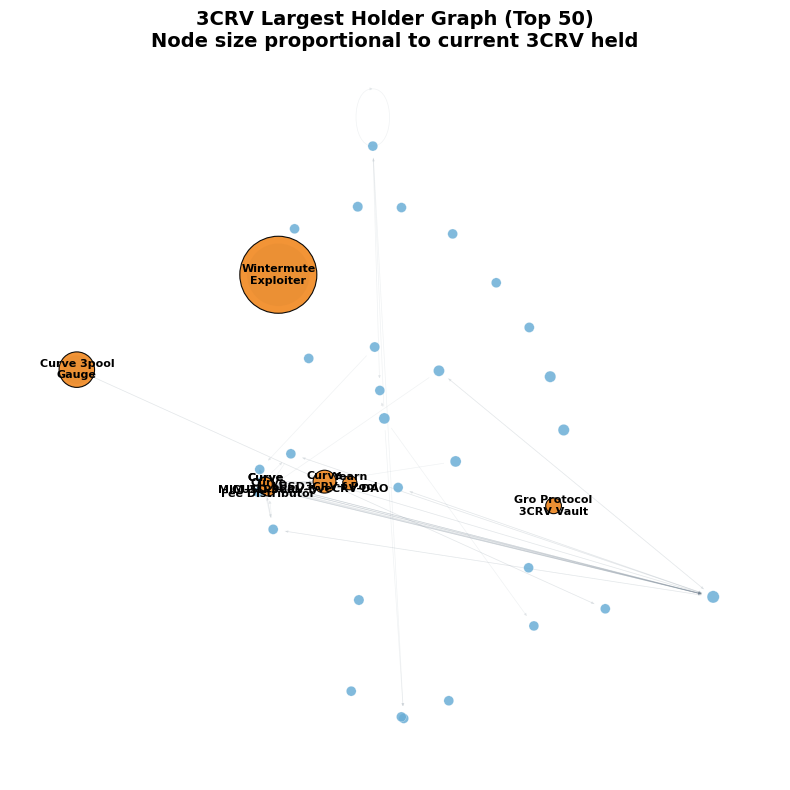

In [5]:
# Compute current holder balances from all LP events
inflows = df.groupby('to_address')['lp_amount'].sum()
outflows = df.groupby('from_address')['lp_amount'].sum()
balances = inflows.subtract(outflows, fill_value=0)
balances = balances.drop(ZERO, errors='ignore')
balances = balances[balances > 1e-6]

# Keep only the largest holders
TOP_N = 50
top_holders = balances.sort_values(ascending=False).head(TOP_N)
sub_nodes = set(top_holders.index)

# IMPORTANT: G_full was built from transfer events only, so some large holders can be
# missing as nodes there (e.g., if holdings came via mint and no transfer activity).
# Build G_top with all top-holder nodes first, then add only edges between them.
G_top = nx.DiGraph()
G_top.add_nodes_from(sub_nodes)
G_top.add_edges_from(
    (u, v, d) for u, v, d in G_full.edges(data=True)
    if u in sub_nodes and v in sub_nodes
)

print(f"Current holders: {len(balances):,}")
print(f"Top holder graph: {G_top.number_of_nodes():,} nodes, {G_top.number_of_edges():,} edges")

# Quick check for Wintermute label presence
wm = '0xe74b28c2eae8679e3ccc3a94d5d0de83ccb84705'
if wm in top_holders.index:
    print(f"Wintermute rank: {top_holders.index.get_loc(wm) + 1}, balance: {top_holders.loc[wm]:,.2f}")
    print(f"Wintermute in plotted nodes: {wm in G_top.nodes()}")

# Build a spread-out layout to reduce overlap
n = max(G_top.number_of_nodes(), 2)
k = 60 / np.sqrt(n)
pos = nx.kamada_kawai_layout(G_top)

# Node sizes from wallet size (log-scaled for readability)
node_bal = np.array([top_holders.get(node, 0.0) for node in G_top.nodes()])
node_sizes = 50 + 2000 * ((node_bal) / (node_bal.max()))

fig, ax = plt.subplots(figsize=(8, 8))

# Draw edges lightly
nx.draw_networkx_edges(
    G_top, pos, ax=ax,
    alpha=0.1, width=0.5,
    edge_color='slategray',
    arrows=True, arrowsize=4
)

# Draw all nodes in one neutral color (no centrality coloring)
nx.draw_networkx_nodes(
    G_top, pos, ax=ax,
    node_size=node_sizes,
    node_color='#6baed6',
    edgecolors='white', linewidths=0.2,
    alpha=0.85
)

# Highlight and label only known major addresses when present
label_nodes = [a for a in KNOWN_LABELS if a in G_top.nodes()]
if label_nodes:
    node_order = list(G_top.nodes())
    size_lookup = {node_order[i]: node_sizes[i] for i in range(len(node_order))}
    nx.draw_networkx_nodes(
        G_top, pos, nodelist=label_nodes, ax=ax,
        node_size=[size_lookup[a] * 1.5 for a in label_nodes],
        node_color='#f28e2b',
        edgecolors='black', linewidths=0.8,
        alpha=0.95
    )
    labels = {a: short_label(a) for a in label_nodes}
    nx.draw_networkx_labels(
        G_top, pos, labels=labels, ax=ax,
        font_size=8, font_weight='bold'
    )

ax.set_title(
    f"3CRV Largest Holder Graph (Top {TOP_N})\nNode size proportional to current 3CRV held",
    fontsize=14, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.show()

### Transfer Network Structure: Core Subgraph

Extract a **core subgraph** of the most-connected addresses (by degree in the transfer graph), showing weighted edges and EOA/contract distinction. This gives insight into how 3CRV actually flows between different types of accounts.

Core subgraph: 300 nodes, 4313 edges
Avg degree: 28.8
Plot graph: 290 nodes, 784 edges
EOAs: 47 | Contracts: 243


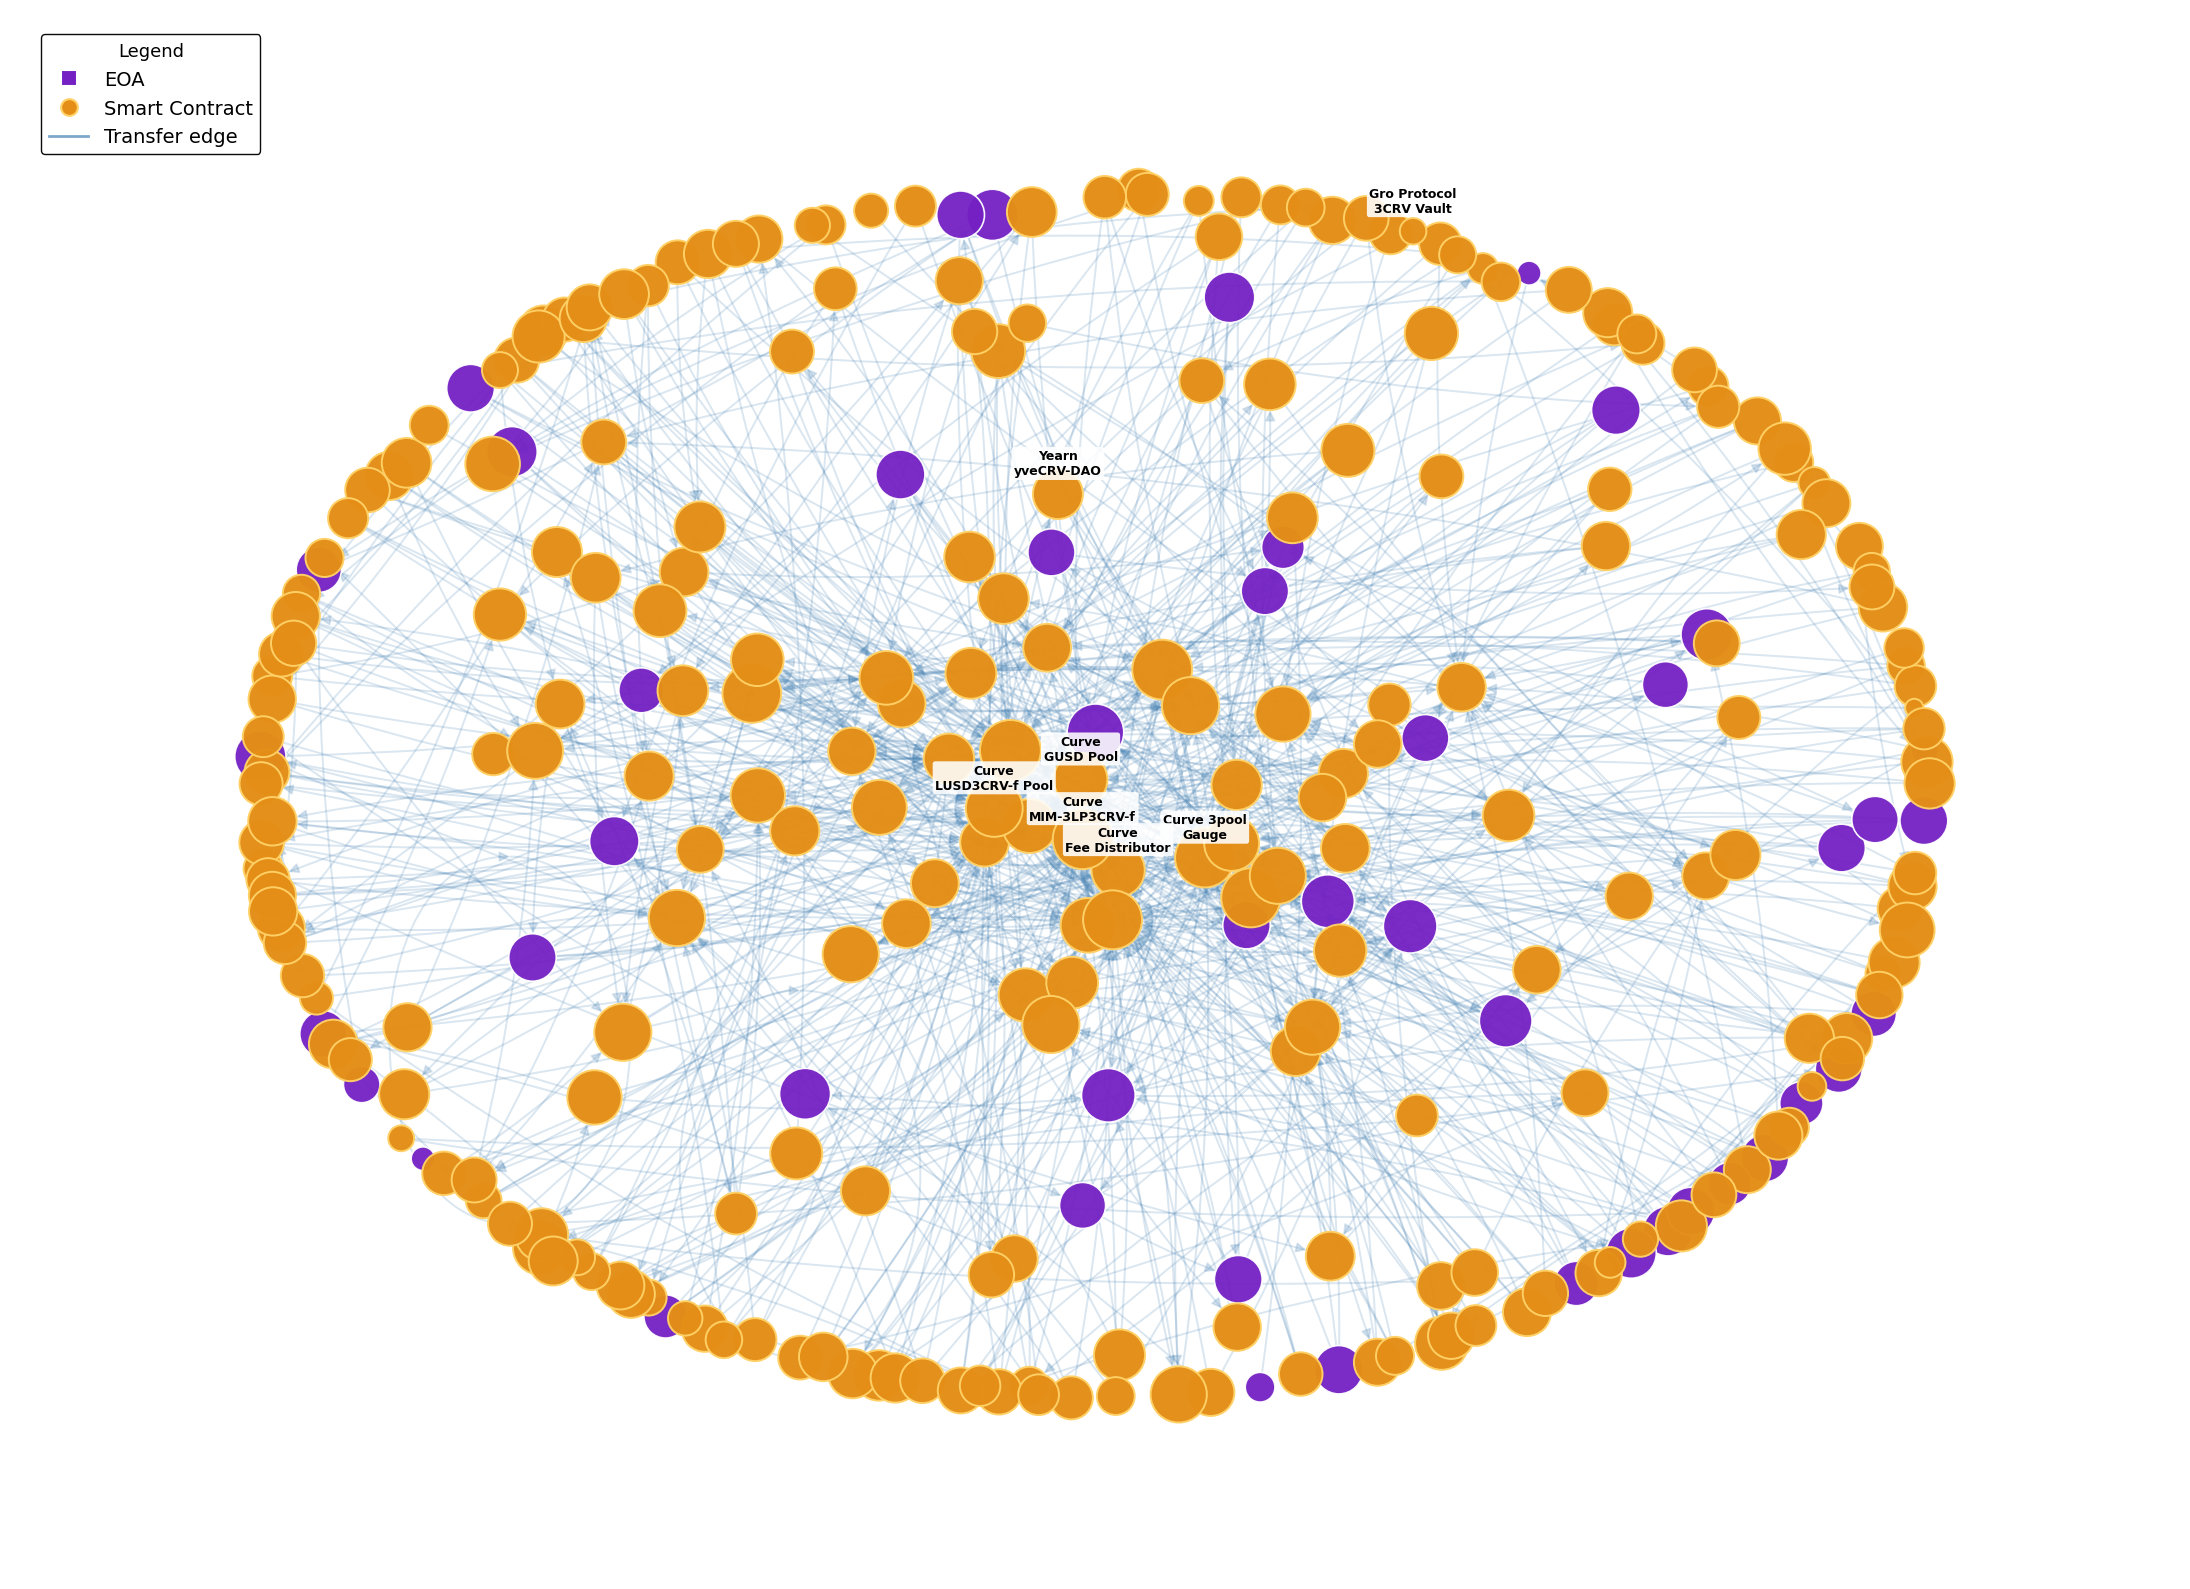

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# ============================================================
# PARAMETERS
# ============================================================
CORE_N = 300                 # top N nodes by degree
TOP_K_OUT_EDGES = 3          # keep top-k strongest outgoing edges per node
KEEP_LARGEST_COMPONENT = True
TOP_LABELS = 10              # number of known nodes to label
FIGSIZE = (22, 16)

# layout tuning
SPRING_K = 250.0               # larger -> more spacing
SPRING_ITER = 500
LAYOUT_SCALE = 10
RADIAL_EXPANSION = 1.       # >1 pushes peripheral nodes farther outward

# styling
BG_COLOR = "white"
EDGE_COLOR = "steelblue"
EOA_COLOR = "#7420C3"        # blue
SC_COLOR = "#E48E17"         # orange
EOA_EDGE = "white"
SC_EDGE = "#FFD166"

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def classify(addr):
    """
    Returns 'eoa' or 'contract'.
    Falls back to 'eoa' if address is missing from address_book.
    """
    return address_book.get(addr, 'eoa')

def safe_short_label(addr):
    """
    Uses short_label(addr) if available, otherwise truncates address.
    """
    try:
        return short_label(addr)
    except Exception:
        return str(addr)[:8] + "..." + str(addr)[-4:]

def radial_expand(pos, factor=1.4):
    """
    Push nodes farther from the center while preserving direction.
    """
    new_pos = {}
    for n, (x, y) in pos.items():
        r = np.sqrt(x*x + y*y)
        if r == 0:
            new_pos[n] = (x, y)
        else:
            scale = 1 + (factor - 1) * r
            new_pos[n] = (x * scale, y * scale)
    return new_pos

def stretch_positions(pos, xscale=2.2, yscale=1.4):
    """
    Rescales positions so nodes occupy more of the canvas.
    Useful to push nodes toward the edges of the figure.
    """
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])

    x_center = xs.mean()
    y_center = ys.mean()

    xs = xs - x_center
    ys = ys - y_center

    max_abs_x = np.max(np.abs(xs)) if len(xs) else 1.0
    max_abs_y = np.max(np.abs(ys)) if len(ys) else 1.0

    stretched = {}
    for n, (x, y) in pos.items():
        x = (x - x_center) / max_abs_x * xscale
        y = (y - y_center) / max_abs_y * yscale
        stretched[n] = (x, y)

    return stretched

# ============================================================
# 1) EXTRACT CORE SUBGRAPH
# ============================================================
degree_seq = [(n, G_full.in_degree(n) + G_full.out_degree(n)) for n in G_full.nodes()]
degree_seq.sort(key=lambda x: x[1], reverse=True)

core_nodes = set(n for n, _ in degree_seq[:CORE_N])
G_core = G_full.subgraph(core_nodes).copy()

print(f"Core subgraph: {G_core.number_of_nodes()} nodes, {G_core.number_of_edges()} edges")
if G_core.number_of_nodes() > 0:
    print(f"Avg degree: {2 * G_core.number_of_edges() / G_core.number_of_nodes():.1f}")

# ============================================================
# 2) FILTER EDGES FOR READABILITY
#    Keep only top-k outgoing weighted edges per node
# ============================================================
G_plot = nx.DiGraph()
G_plot.add_nodes_from(G_core.nodes(data=True))

for n in G_core.nodes():
    out_edges = sorted(
        G_core.out_edges(n, data=True),
        key=lambda x: x[2].get('weight', 1.0),
        reverse=True
    )[:TOP_K_OUT_EDGES]

    for u, v, d in out_edges:
        G_plot.add_edge(u, v, **d)

# Remove isolates created by edge filtering
isolates = list(nx.isolates(G_plot))
G_plot.remove_nodes_from(isolates)

# Optionally keep only largest weakly connected component
if KEEP_LARGEST_COMPONENT and G_plot.number_of_nodes() > 0:
    largest_cc = max(nx.weakly_connected_components(G_plot), key=len)
    G_plot = G_plot.subgraph(largest_cc).copy()

print(f"Plot graph: {G_plot.number_of_nodes()} nodes, {G_plot.number_of_edges()} edges")

# ============================================================
# 3) NODE TYPES
#    EOA = squares
#    SC  = circles
# ============================================================
node_types = {n: classify(n) for n in G_plot.nodes()}
eoa_nodes = [n for n in G_plot.nodes() if node_types[n] == 'eoa']
sc_nodes = [n for n in G_plot.nodes() if node_types[n] == 'contract']

print(f"EOAs: {len(eoa_nodes)} | Contracts: {len(sc_nodes)}")

# ============================================================
# 4) NODE VOLUMES / SIZES
# ============================================================
node_volume = {}
for node in G_plot.nodes():
    in_vol = sum(d.get('weight', 1.0) for _, _, d in G_plot.in_edges(node, data=True))
    out_vol = sum(d.get('weight', 1.0) for _, _, d in G_plot.out_edges(node, data=True))
    node_volume[node] = in_vol + out_vol

max_vol = max(node_volume.values()) if node_volume else 1.0

node_size_map = {
    n: 120 + 1800 * (np.log1p(node_volume[n]) / np.log1p(max_vol))
    for n in G_plot.nodes()
}

# ============================================================
# 5) LAYOUT
#    Use undirected version for layout only
# ============================================================
G_layout = G_plot.to_undirected()

# compress weights used by layout so heavy edges don't collapse everything
for u, v, d in G_layout.edges(data=True):
    d['layout_weight'] = np.log1p(d.get('weight', 1.0))

pos = nx.spring_layout(
    G_layout,
    weight='layout_weight',
    k=SPRING_K / np.sqrt(max(G_layout.number_of_nodes(), 1)),
    iterations=SPRING_ITER,
    seed=42,
    scale=LAYOUT_SCALE
)

# Push nodes farther outward
pos = radial_expand(pos, factor=RADIAL_EXPANSION)

# Stretch to occupy more of the canvas
pos = stretch_positions(pos, xscale=2.5, yscale=1.6)

# ============================================================
# 6) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE, facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

# ----------------------------
# Draw edges
# ----------------------------
edge_weights = np.array([d.get('weight', 1.0) for _, _, d in G_plot.edges(data=True)])
if len(edge_weights) > 0:
    edge_weights_norm = (edge_weights) / (edge_weights.max())
else:
    edge_weights_norm = np.array([])

for (u, v, d), w_norm in zip(G_plot.edges(data=True), edge_weights_norm):
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=EDGE_COLOR,
        width=1.4 + 2.4 * w_norm,
        alpha=0.2 + 0.18 * w_norm,
        arrows=True,                  # cleaner for presentations
        arrowsize=15,
        node_size = [node_size_map[n] for n in G_plot.nodes()],
        connectionstyle='arc3,rad=0.05'
    )

# ----------------------------
# Draw nodes
# EOA = square
# SC  = circle
# ----------------------------
nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=eoa_nodes,
    node_size=[node_size_map[n] for n in eoa_nodes],
    node_color=EOA_COLOR,
    node_shape='o',                   # square
    edgecolors=EOA_EDGE,
    linewidths=1.2,
    alpha=0.95,
    ax=ax
)

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=sc_nodes,
    node_size=[node_size_map[n] for n in sc_nodes],
    node_color=SC_COLOR,
    node_shape='o',                   # circle
    edgecolors=SC_EDGE,
    linewidths=1.4,
    alpha=0.98,
    ax=ax
)

# ============================================================
# 7) LABEL ONLY TOP KNOWN ADDRESSES
# ============================================================
known_set = set(KNOWN_LABELS) if 'KNOWN_LABELS' in globals() else set()

candidate_labels = sorted(
    [n for n in G_plot.nodes() if n in known_set],
    key=lambda n: node_volume.get(n, 0),
    reverse=True
)[:TOP_LABELS]

labels = {n: safe_short_label(n) for n in candidate_labels}

# slightly offset labels upward
label_pos = {n: (pos[n][0], pos[n][1] + 0.08) for n in labels}

nx.draw_networkx_labels(
    G_plot,
    label_pos,
    labels=labels,
    ax=ax,
    font_size=9,
    font_weight='bold',
    font_color='black',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.88,
        boxstyle='round,pad=0.2'
    )
)

# ============================================================
# 8) CLEAN CUSTOM LEGEND
# ============================================================
legend_elements = [
    Line2D(
        [0], [0],
        marker='s',
        color='none',
        label='EOA',
        markerfacecolor=EOA_COLOR,
        markeredgecolor=EOA_EDGE,
        markeredgewidth=1.5,
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Smart Contract',
        markerfacecolor=SC_COLOR,
        markeredgecolor=SC_EDGE,
        markeredgewidth=1.5,
        markersize=12
    ),
    Line2D(
        [0], [0],
        color=EDGE_COLOR,
        lw=2,
        alpha=0.7,
        label='Transfer edge'
    )
]

leg = ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.96,
    fontsize=14,
    title='Legend',
    title_fontsize=13
)

# ============================================================
# 9) TITLE / FINISHING
# ============================================================

# Add a little margin so outer nodes are not clipped
xs = np.array([p[0] for p in pos.values()])
ys = np.array([p[1] for p in pos.values()])
if len(xs) > 0 and len(ys) > 0:
    xpad = 0.15 * (xs.max() - xs.min() + 1e-9)
    ypad = 0.15 * (ys.max() - ys.min() + 1e-9)
    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)

ax.axis('off')
plt.tight_layout()
plt.savefig('3CRV_transfer_network_core_subgraph.png', dpi=300, transparent=True, bbox_inches='tight')

## 2. Classify Nodes (EOA vs Contract)

Addresses in the address book are labelled directly. Addresses **not** in the book (small wallets) are assumed to be EOAs.

In [7]:
def classify(addr):
    return address_book.get(addr, 'eoa')

node_types = {n: classify(n) for n in G_full.nodes()}
nx.set_node_attributes(G_full, node_types, 'type')

eoa_nodes = [n for n, t in node_types.items() if t == 'eoa']
contract_nodes = [n for n, t in node_types.items() if t == 'contract']
print(f"EOA nodes:      {len(eoa_nodes):,}")
print(f"Contract nodes: {len(contract_nodes):,}")

# Build subgraphs
G_eoa = G_full.subgraph(eoa_nodes).copy()
G_contract = G_full.subgraph(contract_nodes).copy()
print(f"\nEOA subgraph:      {G_eoa.number_of_nodes():,} nodes, {G_eoa.number_of_edges():,} edges")
print(f"Contract subgraph: {G_contract.number_of_nodes():,} nodes, {G_contract.number_of_edges():,} edges")

EOA nodes:      27,220
Contract nodes: 2,738

EOA subgraph:      27,220 nodes, 3,057 edges
Contract subgraph: 2,738 nodes, 10,489 edges


- Most addresses are EOA
- Most central addresses are smart contract 
    - Act as plumbing for blockchain activity

## 3. Full-Network Centrality Analysis

Compute centrality on the full directed transfer graph. For large graphs we use approximate betweenness (sampling `k` pivot nodes).

In [8]:
def compute_centralities(G, label='Graph', k_betweenness=200):
    """Compute standard centrality measures on a directed graph."""
    print(f"Computing centralities for {label} ({G.number_of_nodes():,} nodes)...")

    cent = {}
    cent['In-Degree']    = nx.in_degree_centrality(G)
    cent['Out-Degree']   = nx.out_degree_centrality(G)
    cent['PageRank']     = nx.pagerank(G, weight='weight')

    # Betweenness: exact for small graphs, approximate for large ones
    n = G.number_of_nodes()
    if n > 1000:
        k = min(k_betweenness, n)
        cent['Betweenness'] = nx.betweenness_centrality(G, k=k, weight='weight', seed=42)
        print(f"  (betweenness approximated with k={k})")
    else:
        cent['Betweenness'] = nx.betweenness_centrality(G, weight='weight')

    # Weighted in-strength and out-strength (total flow)
    in_strength = {}
    out_strength = {}
    for node in G.nodes():
        in_strength[node] = sum(d.get('weight', 1) for _, _, d in G.in_edges(node, data=True))
        out_strength[node] = sum(d.get('weight', 1) for _, _, d in G.out_edges(node, data=True))
    cent['In-Strength']  = in_strength
    cent['Out-Strength'] = out_strength

    print("  Done.")
    return cent

In [9]:
cent_full = compute_centralities(G_full, label='Full Network')

Computing centralities for Full Network (29,958 nodes)...


  (betweenness approximated with k=200)
  Done.


In [10]:
def short_label(addr):
    return addr[:8] + '...' + addr[-4:]

def top_table(cent_dict, n=15):
    """Return a DataFrame of the top-n nodes for each centrality measure."""
    rows = []
    for name, cent in cent_dict.items():
        for rank, node in enumerate(sorted(cent, key=cent.get, reverse=True)[:n], 1):
            rows.append({
                'Measure': name, 'Rank': rank,
                'Address': short_label(node),
                'Full Address': node,
                'Type': node_types.get(node, 'eoa'),
                'Score': cent[node],
            })
    return pd.DataFrame(rows)

df_full = top_table(cent_full)

# Show top 10 per measure
for name in cent_full:
    print(f"\n{'='*60}")
    print(f"  {name} — Top 10")
    print(f"{'='*60}")
    sub = df_full[df_full['Measure'] == name].head(10)
    for _, r in sub.iterrows():
        print(f"  {r['Rank']:2d}. [{r['Type']:8s}] {r['Address']}  {r['Score']:.6f}")


  In-Degree — Top 10
   1. [contract] 0xbfcf63...952a  0.137063
   2. [contract] 0x5f7f44...0ad0  0.063858
   3. [contract] 0x74de5d...6631  0.059285
   4. [contract] 0x989aeb...ad80  0.047134
   5. [contract] 0x9ca855...179f  0.037053
   6. [contract] 0xbfbec7...ea6a  0.033381
   7. [contract] 0xb0d092...c0be  0.030143
   8. [contract] 0x99a584...788f  0.029509
   9. [contract] 0xf0d4c1...8b8d  0.028240
  10. [contract] 0x45312e...cd4e  0.026872

  Out-Degree — Top 10
   1. [contract] 0x7091db...d2ea  0.433321
   2. [contract] 0xa464e6...22dc  0.164068
   3. [contract] 0xbfcf63...952a  0.124245
   4. [contract] 0xf403c1...ae31  0.042528
   5. [contract] 0xaa0c3f...e434  0.038622
   6. [contract] 0x9ca855...179f  0.032046
   7. [contract] 0xbfbec7...ea6a  0.031979
   8. [contract] 0xc5bddf...502a  0.025670
   9. [contract] 0x633120...be0f  0.017258
  10. [contract] 0xe95ebc...37a4  0.014788

  PageRank — Top 10
   1. [contract] 0xa79828...3359  0.081042
   2. [contract] 0xbfcf63...952

### Full Network — Centrality Distributions by Node Type

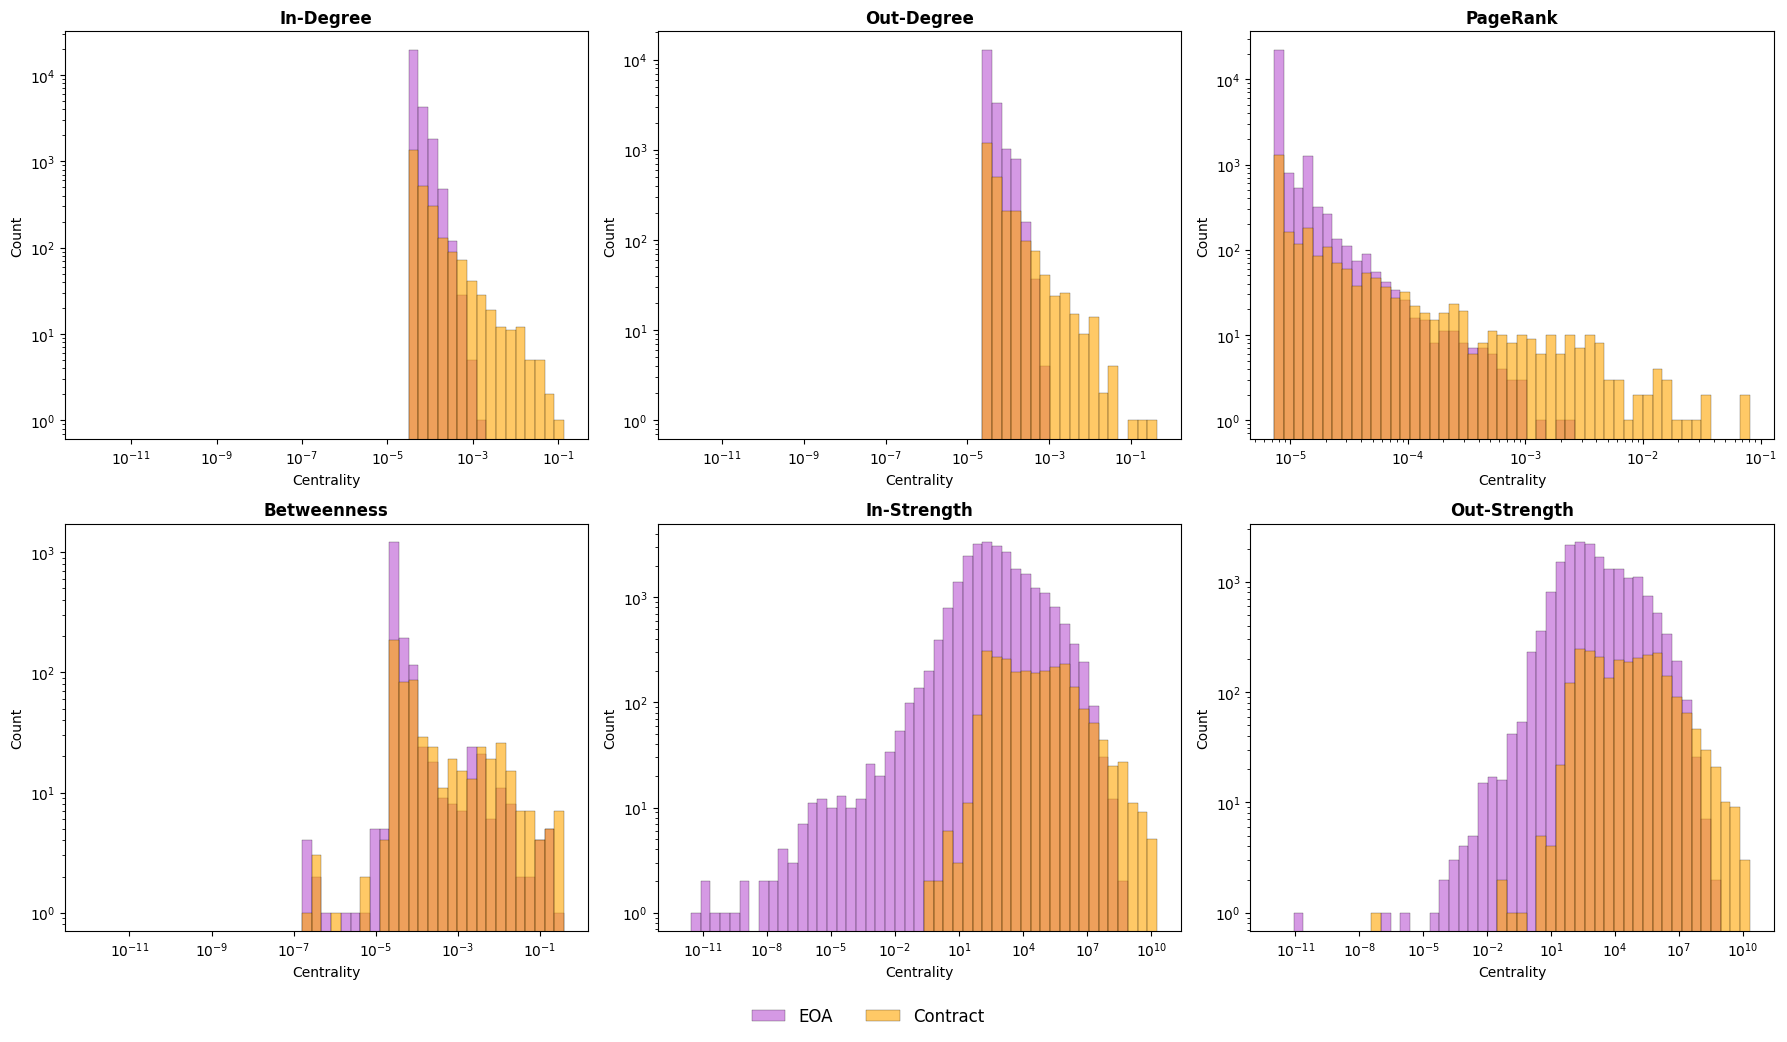

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (name, cent) in zip(axes.flat, cent_full.items()):
    eoa_vals = [cent[n] for n in eoa_nodes if n in cent]
    sc_vals  = [cent[n] for n in contract_nodes if n in cent]

    # Log-scale histograms (most values are near zero)
    bins = np.logspace(
        np.log10(max(min(cent.values()), 1e-12)),
        np.log10(max(cent.values())),
        50
    )
    ax.hist(eoa_vals, bins=bins, alpha=0.6, label='EOA', edgecolor='k', linewidth=0.3, color = 'mediumorchid')
    ax.hist(sc_vals, bins=bins, alpha=0.6, label='Contract', edgecolor='k', linewidth=0.3, color = 'orange')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Centrality')
    ax.set_ylabel('Count')

# axes.flat[-1].axis('off')
# fig.suptitle('Full Network — Centrality Distributions (EOA vs Contract)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.legend(fontsize=12, ncols = 2, frameon=False, bbox_to_anchor=(-0.48, -0.15))

plt.savefig('3CRV_centrality_distributions.png', dpi=300, transparent=True, bbox_inches='tight')

### Full Network — Freeman Centralization

In [12]:
def compute_freeman_centralisation(cent):
    """
    Compute Freeman centralisation from a centrality dictionary produced by
    compute_centralities(G).

    Returns a dict:
      - In-Degree, Out-Degree, Betweenness: standard Freeman-normalized values in [0,1]
      - In-Strength, Out-Strength: normalized by (n-1)*total_weight
      - PageRank:
          * 'raw'    = raw Freeman centralisation
          * 'scaled' = raw/(n-1), a simple [0,1]-style scaling (non-standard)
    """
    # number of nodes
    n = len(next(iter(cent.values()))) if cent else 0

    def freeman_raw(cdict):
        vals = list(cdict.values())
        if not vals:
            return 0.0
        cmax = max(vals)
        return sum(cmax - v for v in vals)

    results = {}

    # ---- Degree centralities ----
    # nx.in_degree_centrality / out_degree_centrality are already normalized by (n-1)
    for key in ['In-Degree', 'Out-Degree']:
        raw = freeman_raw(cent[key])
        denom = (n - 1) if n > 1 else 1.0
        results[key] = raw / denom

    # ---- Betweenness centrality ----
    # nx.betweenness_centrality uses normalized=True by default
    # so the Freeman denominator is again (n-1)
    raw = freeman_raw(cent['Betweenness'])
    denom = (n - 1) if n > 1 else 1.0
    results['Betweenness'] = raw / denom

    # ---- Strength centralities ----
    # Raw weighted degree totals; normalize by (n-1) * total weight
    for key in ['In-Strength', 'Out-Strength']:
        raw = freeman_raw(cent[key])
        total_weight = sum(cent[key].values())
        denom = (n - 1) * total_weight if (n > 1 and total_weight > 0) else 1.0
        results[key] = raw / denom if denom != 0 else 0.0

    # ---- PageRank ----
    # No classical Freeman normalization exists for PageRank.
    # We return:
    #   - raw Freeman centralisation
    #   - a simple scaled version raw/(n-1), which lies in [0,1] but is non-standard
    pr_raw = freeman_raw(cent['PageRank'])
    results['PageRank'] = pr_raw / (n - 1) if n > 1 else 0.0

    return results

In [13]:
freeman_full = compute_freeman_centralisation(cent_full)

for k, v in freeman_full.items():
    print(f"{k:16s}: {v:.6f}")

In-Degree       : 0.136986
Out-Degree      : 0.433254
Betweenness     : 0.391634
In-Strength     : 0.133377
Out-Strength    : 0.158260
PageRank        : 0.081012


Ego graph size: 29 nodes, 60 edges


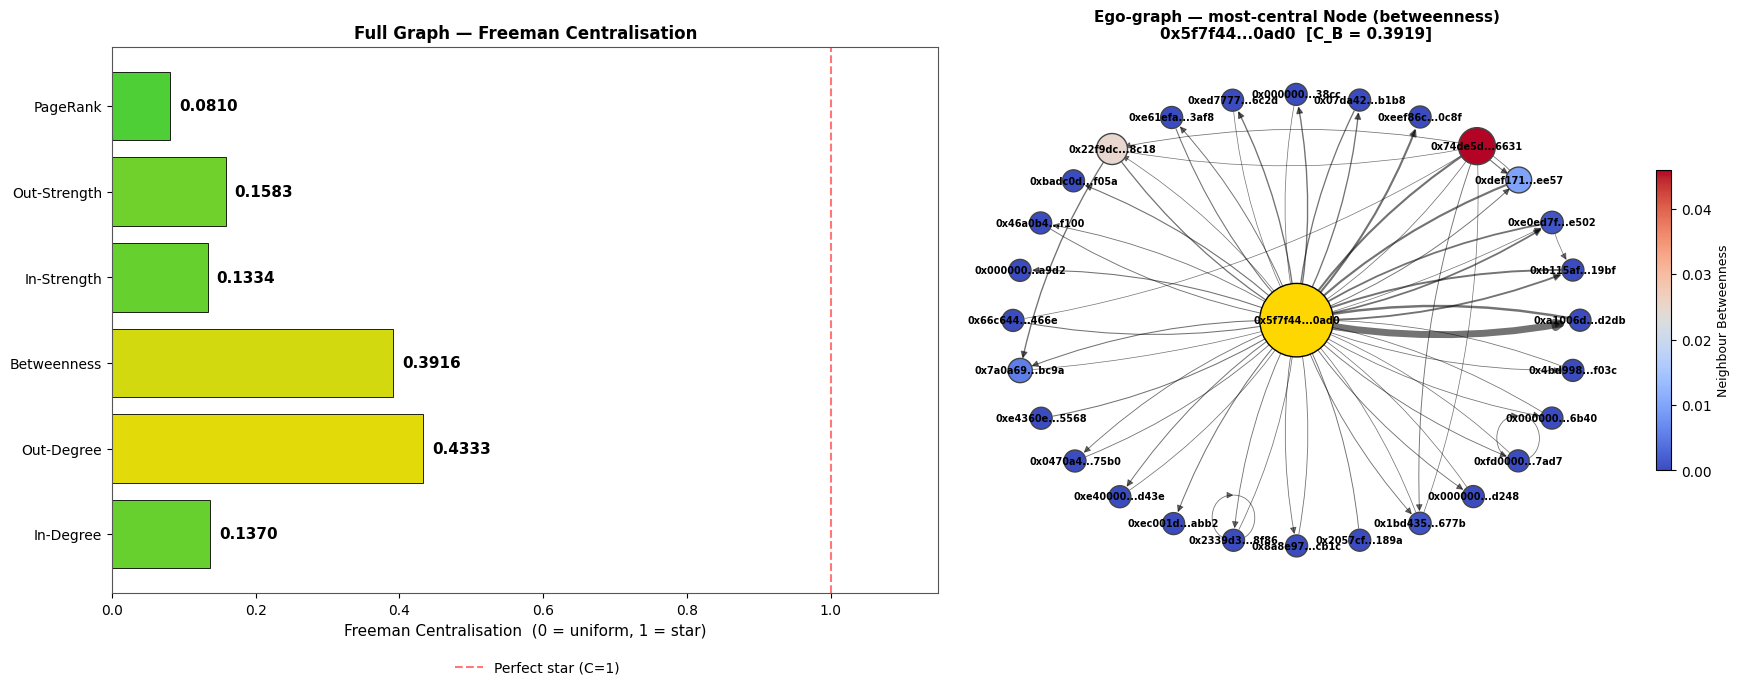

In [17]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np


# ── Freeman scores (exclude non-standard raw PageRank centralisation) ────────
preferred_measures = [
    'In-Degree',
    'Out-Degree',
    'Betweenness',
    'In-Strength',
    'Out-Strength',
    'PageRank',   # keep scaled version only
]
fc_scores = {m: freeman_full[m] for m in preferred_measures if m in freeman_full}

fig, (ax_bar, ax_ego) = plt.subplots(1, 2, figsize=(18, 7))
# fig.patch.set_facecolor('#111111')

# ── Left: horizontal bar chart ────────────────────────────────────────────────
measures = list(fc_scores.keys())
scores   = [fc_scores[m] for m in measures]

# green (0 = uniform) → yellow → red (1 = star)
bar_cmap   = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#2ecc40', '#ffdc00', '#ff4136']
)
bar_colors = [bar_cmap(min(max(s, 0), 1)) for s in scores]

bars = ax_bar.barh(measures, scores, color=bar_colors, edgecolor='black', linewidth=0.6)
# ax_bar.set_facecolor('#1a1a1a')
ax_bar.set_xlim(0, 1.15)
ax_bar.set_xlabel('Freeman Centralisation  (0 = uniform, 1 = star)', fontsize=11)
ax_bar.set_title('Full Graph — Freeman Centralisation', fontweight='bold', fontsize=12)
ax_bar.axvline(1.0, color='#ff5555', lw=1.5, linestyle='--', alpha=0.8, label='Perfect star (C=1)')
for spine in ax_bar.spines.values():
    spine.set_edgecolor('#555555')

for bar, s in zip(bars, scores):
    ax_bar.text(
        s + 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{s:.4f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

ax_bar.legend(bbox_to_anchor=(.4, -.1), frameon = False, loc='upper left', fontsize=10)

# ── Right: ego-graph of most-central node (by betweenness) ───────────────────
hub = max(cent_full['Betweenness'], key=cent_full['Betweenness'].get)
NEIGH_CAP = 28

def edge_weight_sum(G, u, v):
    """Return total weight on edge(s) u -> v for DiGraph or MultiDiGraph."""
    if not G.has_edge(u, v):
        return 0.0

    if G.is_multigraph():
        return sum(attr.get('weight', 1) for attr in G[u][v].values())
    else:
        return G[u][v].get('weight', 1)

def hub_edge_weight(node):
    """Combined weight between hub and node in both directions."""
    return edge_weight_sum(G_full, hub, node) + edge_weight_sum(G_full, node, hub)

# SAFER: do not build nx.ego_graph first
raw_neighbours = set(G_full.predecessors(hub)) | set(G_full.successors(hub))
raw_neighbours.discard(hub)

# Cap neighbours before building the subgraph
raw_neighbours = sorted(raw_neighbours, key=hub_edge_weight, reverse=True)[:NEIGH_CAP]

ego_nodes = [hub] + raw_neighbours
ego = G_full.subgraph(ego_nodes).copy()

print(f"Ego graph size: {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")

# Layout: hub pinned at centre, neighbours on a ring as initial seed
angles   = np.linspace(0, 2 * np.pi, max(len(raw_neighbours), 1), endpoint=False)
init_pos = {hub: np.array([0.0, 0.0])}
for node, angle in zip(raw_neighbours, angles):
    init_pos[node] = np.array([np.cos(angle), np.sin(angle)])

ego_pos = nx.spring_layout(
    ego,
    pos=init_pos,
    fixed=[hub],
    k=250,
    seed=42,
    iterations=60
)

# Visual attributes
bet        = cent_full['Betweenness']
neigh_vals = [bet.get(n, 0) for n in raw_neighbours]
vmax_bet   = max(neigh_vals) if neigh_vals else 1e-9
norm       = mcolors.Normalize(vmin=0, vmax=max(vmax_bet, 1e-9))
node_cmap  = plt.colormaps['coolwarm']  # higher betweenness = warmer color

node_col, node_sz, node_ec = [], [], []
for node in ego.nodes():
    if node == hub:
        node_col.append('gold')
        node_sz.append(2800)
        node_ec.append('black')
    else:
        b = bet.get(node, 0)
        node_col.append(node_cmap(norm(b)))
        node_sz.append(250 + b * 10000)
        node_ec.append('#444444')

edge_data = list(ego.edges(data=True))
if edge_data:
    max_w = max(d.get('weight', 1) for _, _, d in edge_data)
    max_w = max(max_w, 1e-9)
    edge_w = [0.5 + 4.5 * d.get('weight', 1) / max_w for _, _, d in edge_data]
else:
    edge_w = []

ax_ego.set_facecolor('#111111')

nx.draw_networkx_edges(
    ego,
    ego_pos,
    ax=ax_ego,
    edgelist=[(u, v) for u, v, _ in edge_data],
    width=edge_w,
    alpha=0.55,
    edge_color='black',
    arrows=True,
    arrowsize=10,
    connectionstyle='arc3,rad=0.1'
)

nx.draw_networkx_nodes(
    ego,
    ego_pos,
    ax=ax_ego,
    node_size=node_sz,
    node_color=node_col,
    edgecolors=node_ec,
    linewidths=1.0
)

nx.draw_networkx_labels(
    ego,
    ego_pos,
    ax=ax_ego,
    labels={n: safe_short_label(n) for n in ego.nodes()},
    font_size=7,
    font_color='black',
    font_weight='bold'
)

hub_str  = safe_short_label(hub)
hub_cval = bet[hub]
hub_fmt  = f'{hub_cval:.2e}' if hub_cval < 0.001 else f'{hub_cval:.4f}'
ax_ego.set_title(
    f'Ego-graph — most-central Node (betweenness)\n{hub_str}  [C_B = {hub_fmt}]',
    fontweight='bold',
    color='black',
    fontsize=11
)
ax_ego.axis('off')

# Colorbar for neighbour betweenness
sm = cm.ScalarMappable(cmap=node_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_ego, shrink=0.55, pad=0.02)
cbar.set_label('Neighbour Betweenness', color='black', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

plt.tight_layout()
plt.savefig(
    '3CRV_full_centrality_viz.png',
    dpi=300,  # slightly safer than 200 on memory-constrained notebook servers
    bbox_inches='tight',
    transparent = True
)
plt.show()

## 4. EOA-Only Subgraph Centrality

Restrict to transfers between EOAs only — how does centrality change when smart contracts are removed?

In [18]:
cent_eoa = compute_centralities(G_eoa, label='EOA subgraph')

df_eoa = top_table(cent_eoa)
for name in cent_eoa:
    print(f"\n  {name} — Top 5 EOAs")
    sub = df_eoa[df_eoa['Measure'] == name].head(5)
    for _, r in sub.iterrows():
        print(f"    {r['Rank']}. {r['Address']}  {r['Score']:.6f}")

Computing centralities for EOA subgraph (27,220 nodes)...
  (betweenness approximated with k=200)
  Done.

  In-Degree — Top 5 EOAs
    1. 0x0aba70...da2c  0.001176
    2. 0xb10fa3...92d5  0.000845
    3. 0xaedf5e...4771  0.000735
    4. 0x5ecd9a...7a4e  0.000698
    5. 0xc62eec...c57a  0.000698

  Out-Degree — Top 5 EOAs
    1. 0x2ed6c4...94ee  0.000992
    2. 0xc1d5ac...5cb7  0.000698
    3. 0x0936ca...3bcf  0.000331
    4. 0x4902b2...449e  0.000331
    5. 0x4fbcd2...5bf2  0.000331

  PageRank — Top 5 EOAs
    1. 0xcd6b98...9799  0.000931
    2. 0x0aba70...da2c  0.000554
    3. 0x5ecd9a...7a4e  0.000545
    4. 0xf96da4...71b5  0.000538
    5. 0x39041f...7ebc  0.000493

  Betweenness — Top 5 EOAs
    1. 0x7f9c53...0a9d  0.000001
    2. 0x1fd805...f7fd  0.000001
    3. 0x9246e1...3fbc  0.000000
    4. 0x9014e4...0c8f  0.000000
    5. 0x5586a8...465a  0.000000

  In-Strength — Top 5 EOAs
    1. 0x064c60...5caf  39179914.150110
    2. 0x68c88f...c2b7  32251903.350000
    3. 0x1b3035...51

In [19]:
freeman_eoa = compute_freeman_centralisation(cent_eoa)

for k, v in freeman_eoa.items():
    print(f"{k:16s}: {v:.6f}")

In-Degree       : 0.001172
Out-Degree      : 0.000988
Betweenness     : 0.000001
In-Strength     : 0.037281
Out-Strength    : 0.037281
PageRank        : 0.000894


Ego graph size: 5 nodes, 5 edges


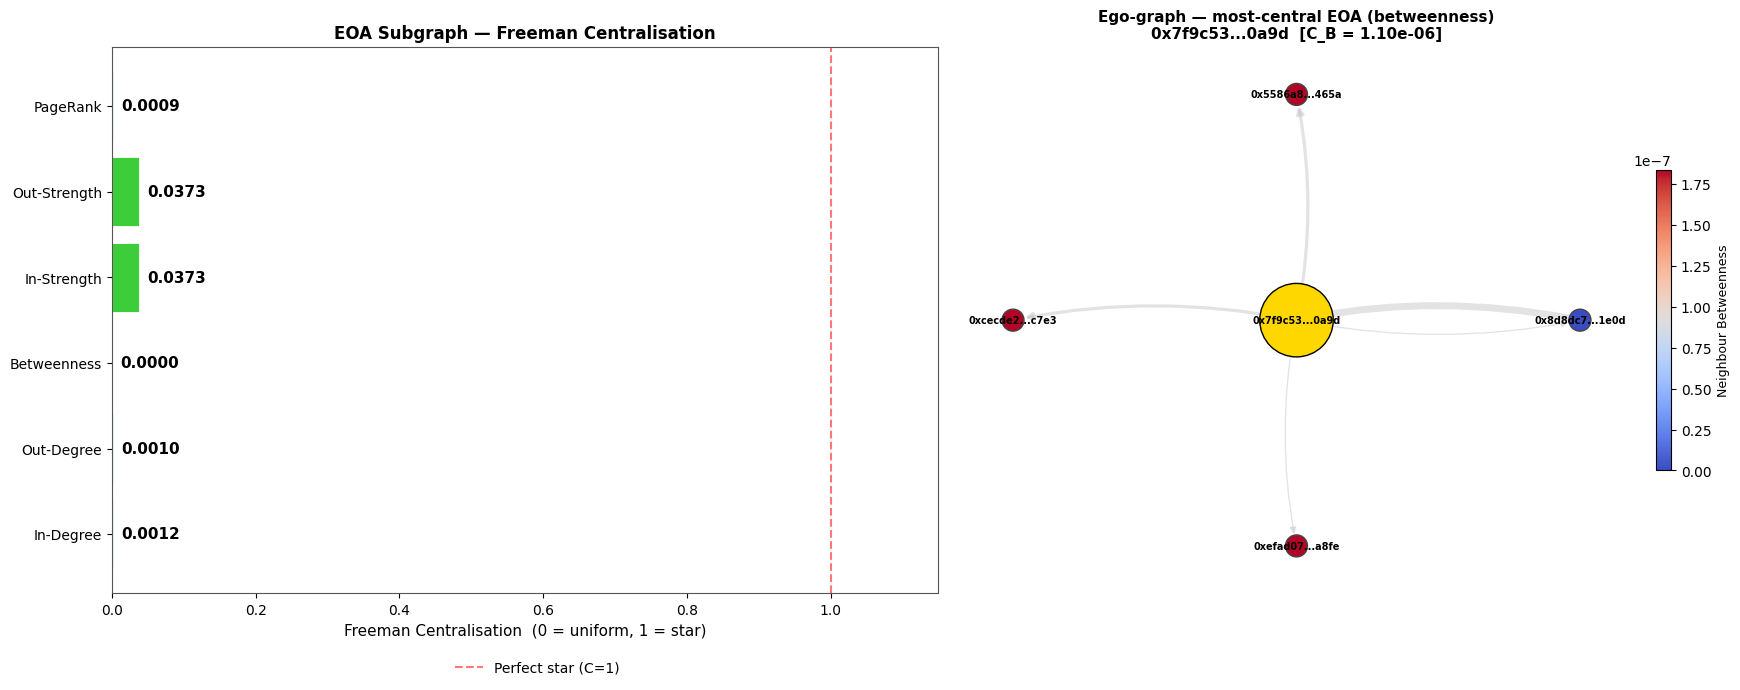

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np


# ── Freeman scores (exclude non-standard raw PageRank centralisation) ────────
preferred_measures = [
    'In-Degree',
    'Out-Degree',
    'Betweenness',
    'In-Strength',
    'Out-Strength',
    'PageRank',   # keep scaled version only
]
fc_scores = {m: freeman_eoa[m] for m in preferred_measures if m in freeman_eoa}

fig, (ax_bar, ax_ego) = plt.subplots(1, 2, figsize=(18, 7))
# fig.patch.set_facecolor('#111111')

# ── Left: horizontal bar chart ────────────────────────────────────────────────
measures = list(fc_scores.keys())
scores   = [fc_scores[m] for m in measures]

# green (0 = uniform) → yellow → red (1 = star)
bar_cmap   = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#2ecc40', '#ffdc00', '#ff4136']
)
bar_colors = [bar_cmap(min(max(s, 0), 1)) for s in scores]

bars = ax_bar.barh(measures, scores, color=bar_colors, edgecolor='white', linewidth=0.6)
# ax_bar.set_facecolor('#1a1a1a')
ax_bar.set_xlim(0, 1.15)
ax_bar.set_xlabel('Freeman Centralisation  (0 = uniform, 1 = star)', color='black', fontsize=11)
ax_bar.set_title('EOA Subgraph — Freeman Centralisation', fontweight='bold', color='black', fontsize=12)
ax_bar.axvline(1.0, color='#ff5555', lw=1.5, linestyle='--', alpha=0.8, label='Perfect star (C=1)')
# ax_bar.tick_params(colors='white')
for spine in ax_bar.spines.values():
    spine.set_edgecolor('#555555')

for bar, s in zip(bars, scores):
    ax_bar.text(
        s + 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{s:.4f}',
        va='center',
        fontsize=11,
        color='black',
        fontweight='bold'
    )

ax_bar.legend(bbox_to_anchor=(.4, -.1), frameon = False, loc='upper left', fontsize=10)

# ── Right: ego-graph of most-central node (by betweenness) ───────────────────
hub = max(cent_eoa['Betweenness'], key=cent_eoa['Betweenness'].get)
NEIGH_CAP = 28

def edge_weight_sum(G, u, v):
    """Return total weight on edge(s) u -> v for DiGraph or MultiDiGraph."""
    if not G.has_edge(u, v):
        return 0.0

    if G.is_multigraph():
        return sum(attr.get('weight', 1) for attr in G[u][v].values())
    else:
        return G[u][v].get('weight', 1)

def hub_edge_weight(node):
    """Combined weight between hub and node in both directions."""
    return edge_weight_sum(G_eoa, hub, node) + edge_weight_sum(G_eoa, node, hub)

# SAFER: do not build nx.ego_graph first
raw_neighbours = set(G_eoa.predecessors(hub)) | set(G_eoa.successors(hub))
raw_neighbours.discard(hub)

# Cap neighbours before building the subgraph
raw_neighbours = sorted(raw_neighbours, key=hub_edge_weight, reverse=True)[:NEIGH_CAP]

ego_nodes = [hub] + raw_neighbours
ego = G_eoa.subgraph(ego_nodes).copy()

print(f"Ego graph size: {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")

# Layout: hub pinned at centre, neighbours on a ring as initial seed
angles   = np.linspace(0, 2 * np.pi, max(len(raw_neighbours), 1), endpoint=False)
init_pos = {hub: np.array([0.0, 0.0])}
for node, angle in zip(raw_neighbours, angles):
    init_pos[node] = np.array([np.cos(angle), np.sin(angle)])

ego_pos = nx.spring_layout(
    ego,
    pos=init_pos,
    fixed=[hub],
    k=150,
    seed=42,
    iterations=60
)

# Visual attributes
bet        = cent_eoa['Betweenness']
neigh_vals = [bet.get(n, 0) for n in raw_neighbours]
vmax_bet   = max(neigh_vals) if neigh_vals else 1e-9
norm       = mcolors.Normalize(vmin=0, vmax=max(vmax_bet, 1e-9))
node_cmap  = plt.colormaps['coolwarm']  # higher betweenness = warmer color

node_col, node_sz, node_ec = [], [], []
for node in ego.nodes():
    if node == hub:
        node_col.append('gold')
        node_sz.append(2800)
        node_ec.append('black')
    else:
        b = bet.get(node, 0)
        node_col.append(node_cmap(norm(b)))
        node_sz.append(250 + b * 10000)
        node_ec.append('#444444')

edge_data = list(ego.edges(data=True))
if edge_data:
    max_w = max(d.get('weight', 1) for _, _, d in edge_data)
    max_w = max(max_w, 1e-9)
    edge_w = [0.5 + 4.5 * d.get('weight', 1) / max_w for _, _, d in edge_data]
else:
    edge_w = []

# ax_ego.set_facecolor('#111111')

nx.draw_networkx_edges(
    ego,
    ego_pos,
    ax=ax_ego,
    edgelist=[(u, v) for u, v, _ in edge_data],
    width=edge_w,
    alpha=0.55,
    edge_color='#cccccc',
    arrows=True,
    arrowsize=10,
    connectionstyle='arc3,rad=0.1'
)

nx.draw_networkx_nodes(
    ego,
    ego_pos,
    ax=ax_ego,
    node_size=node_sz,
    node_color=node_col,
    edgecolors=node_ec,
    linewidths=1.0
)

nx.draw_networkx_labels(
    ego,
    ego_pos,
    ax=ax_ego,
    labels={n: safe_short_label(n) for n in ego.nodes()},
    font_size=7,
    font_color='black',
    font_weight='bold'
)

hub_str  = safe_short_label(hub)
hub_cval = bet[hub]
hub_fmt  = f'{hub_cval:.2e}' if hub_cval < 0.001 else f'{hub_cval:.4f}'
ax_ego.set_title(
    f'Ego-graph — most-central EOA (betweenness)\n{hub_str}  [C_B = {hub_fmt}]',
    fontweight='bold',
    color='black',
    fontsize=11
)
ax_ego.axis('off')

# Colorbar for neighbour betweenness
sm = cm.ScalarMappable(cmap=node_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_ego, shrink=0.55, pad=0.02)
cbar.set_label('Neighbour Betweenness', color='black', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

plt.tight_layout()
plt.savefig(
    '3CRV_eoa_centrality_viz.png',
    dpi=300,  # slightly safer than 200 on memory-constrained notebook servers
    bbox_inches='tight',
    transparent = True
)
plt.show()

## 5. Contract-Only Subgraph Centrality

Now restrict to transfers between smart contracts only.

In [21]:
cent_contract = compute_centralities(G_contract, label='Contract subgraph')

df_contract = top_table(cent_contract)
for name in cent_contract:
    print(f"\n  {name} — Top 5 Contracts")
    sub = df_contract[df_contract['Measure'] == name].head(5)
    for _, r in sub.iterrows():
        print(f"    {r['Rank']}. {r['Address']}  {r['Score']:.6f}")

Computing centralities for Contract subgraph (2,738 nodes)...
  (betweenness approximated with k=200)
  Done.

  In-Degree — Top 5 Contracts
    1. 0xbfcf63...952a  0.104129
    2. 0xd632f2...ed3b  0.088053
    3. 0xed279f...f0ca  0.082207
    4. 0x5f7f44...0ad0  0.071611
    5. 0x5a6a4d...f41b  0.070881

  Out-Degree — Top 5 Contracts
    1. 0x7091db...d2ea  0.173913
    2. 0xa464e6...22dc  0.096456
    3. 0xbfcf63...952a  0.095725
    4. 0xd632f2...ed3b  0.074900
    5. 0xed279f...f0ca  0.074169

  PageRank — Top 5 Contracts
    1. 0xa79828...3359  0.145516
    2. 0x5a6a4d...f41b  0.051767
    3. 0xbfcf63...952a  0.047779
    4. 0xd632f2...ed3b  0.032206
    5. 0x989aeb...ad80  0.031112

  Betweenness — Top 5 Contracts
    1. 0x3c62d7...995a  0.272653
    2. 0xd2b37a...612b  0.202061
    3. 0xbfcf63...952a  0.178154
    4. 0x45312e...cd4e  0.160523
    5. 0x5f7f44...0ad0  0.159418

  In-Strength — Top 5 Contracts
    1. 0xa79828...3359  18238320142.086887
    2. 0xbfcf63...952a  1018

In [22]:
freeman_contract = compute_freeman_centralisation(cent_contract)

for k, v in freeman_contract.items():
    print(f"{k:16s}: {v:.6f}")

In-Degree       : 0.102766
Out-Degree      : 0.172576
Betweenness     : 0.270321
In-Strength     : 0.153924
Out-Strength    : 0.182701
PageRank        : 0.145204


Ego graph size: 28 nodes, 65 edges


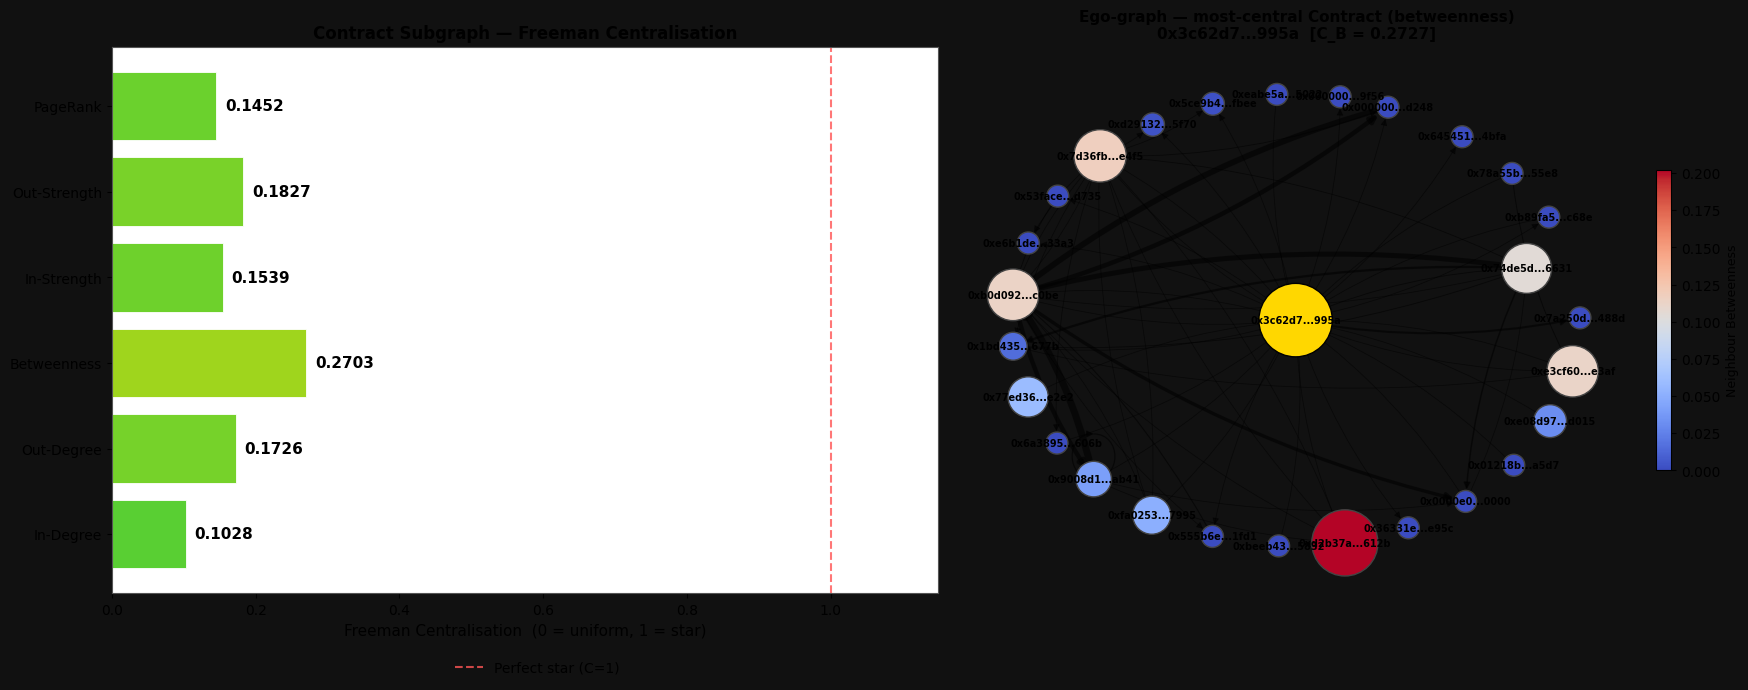

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np


# ── Freeman scores (exclude non-standard raw PageRank centralisation) ────────
preferred_measures = [
    'In-Degree',
    'Out-Degree',
    'Betweenness',
    'In-Strength',
    'Out-Strength',
    'PageRank',   # keep scaled version only
]
fc_scores = {m: freeman_contract[m] for m in preferred_measures if m in freeman_contract}

fig, (ax_bar, ax_ego) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#111111')

# ── Left: horizontal bar chart ────────────────────────────────────────────────
measures = list(fc_scores.keys())
scores   = [fc_scores[m] for m in measures]

# green (0 = uniform) → yellow → red (1 = star)
bar_cmap   = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#2ecc40', '#ffdc00', '#ff4136']
)
bar_colors = [bar_cmap(min(max(s, 0), 1)) for s in scores]

bars = ax_bar.barh(measures, scores, color=bar_colors, edgecolor='white', linewidth=0.6)
# ax_bar.set_facecolor('#1a1a1a')
ax_bar.set_xlim(0, 1.15)
ax_bar.set_xlabel('Freeman Centralisation  (0 = uniform, 1 = star)', color='black', fontsize=11)
ax_bar.set_title('Contract Subgraph — Freeman Centralisation', fontweight='bold', color='black', fontsize=12)
ax_bar.axvline(1.0, color='#ff5555', lw=1.5, linestyle='--', alpha=0.8, label='Perfect star (C=1)')
for spine in ax_bar.spines.values():
    spine.set_edgecolor('#555555')

for bar, s in zip(bars, scores):
    ax_bar.text(
        s + 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{s:.4f}',
        va='center',
        fontsize=11,
        color='black',
        fontweight='bold'
    )

ax_bar.legend(bbox_to_anchor=(.4, -.1), frameon = False, loc='upper left', fontsize=10)

# ── Right: ego-graph of most-central node (by betweenness) ───────────────────
hub = max(cent_contract['Betweenness'], key=cent_contract['Betweenness'].get)
NEIGH_CAP = 28

def edge_weight_sum(G, u, v):
    """Return total weight on edge(s) u -> v for DiGraph or MultiDiGraph."""
    if not G.has_edge(u, v):
        return 0.0

    if G.is_multigraph():
        return sum(attr.get('weight', 1) for attr in G[u][v].values())
    else:
        return G[u][v].get('weight', 1)

def hub_edge_weight(node):
    """Combined weight between hub and node in both directions."""
    return edge_weight_sum(G_contract, hub, node) + edge_weight_sum(G_contract, node, hub)

# SAFER: do not build nx.ego_graph first
raw_neighbours = set(G_contract.predecessors(hub)) | set(G_contract.successors(hub))
raw_neighbours.discard(hub)

# Cap neighbours before building the subgraph
raw_neighbours = sorted(raw_neighbours, key=hub_edge_weight, reverse=True)[:NEIGH_CAP]

ego_nodes = [hub] + raw_neighbours
ego = G_contract.subgraph(ego_nodes).copy()

print(f"Ego graph size: {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")

# Layout: hub pinned at centre, neighbours on a ring as initial seed
angles   = np.linspace(0, 2 * np.pi, max(len(raw_neighbours), 1), endpoint=False)
init_pos = {hub: np.array([0.0, 0.0])}
for node, angle in zip(raw_neighbours, angles):
    init_pos[node] = np.array([np.cos(angle), np.sin(angle)])

ego_pos = nx.spring_layout(
    ego,
    pos=init_pos,
    fixed=[hub],
    k=250,
    seed=42,
    iterations=60
)

# Visual attributes
bet        = cent_contract['Betweenness']
neigh_vals = [bet.get(n, 0) for n in raw_neighbours]
vmax_bet   = max(neigh_vals) if neigh_vals else 1e-9
norm       = mcolors.Normalize(vmin=0, vmax=max(vmax_bet, 1e-9))
node_cmap  = plt.colormaps['coolwarm']  # higher betweenness = warmer color

node_col, node_sz, node_ec = [], [], []
for node in ego.nodes():
    if node == hub:
        node_col.append('gold')
        node_sz.append(2800)
        node_ec.append('black')
    else:
        b = bet.get(node, 0)
        node_col.append(node_cmap(norm(b)))
        node_sz.append(250 + b * 10000)
        node_ec.append('#444444')

edge_data = list(ego.edges(data=True))
if edge_data:
    max_w = max(d.get('weight', 1) for _, _, d in edge_data)
    max_w = max(max_w, 1e-9)
    edge_w = [0.5 + 4.5 * d.get('weight', 1) / max_w for _, _, d in edge_data]
else:
    edge_w = []

# ax_ego.set_facecolor('#111111')

nx.draw_networkx_edges(
    ego,
    ego_pos,
    ax=ax_ego,
    edgelist=[(u, v) for u, v, _ in edge_data],
    width=edge_w,
    alpha=0.55,
    edge_color='black',
    arrows=True,
    arrowsize=10,
    connectionstyle='arc3,rad=0.1'
)

nx.draw_networkx_nodes(
    ego,
    ego_pos,
    ax=ax_ego,
    node_size=node_sz,
    node_color=node_col,
    edgecolors=node_ec,
    linewidths=1.0
)

nx.draw_networkx_labels(
    ego,
    ego_pos,
    ax=ax_ego,
    labels={n: safe_short_label(n) for n in ego.nodes()},
    font_size=7,
    font_color='black',
    font_weight='bold'
)

hub_str  = safe_short_label(hub)
hub_cval = bet[hub]
hub_fmt  = f'{hub_cval:.2e}' if hub_cval < 0.001 else f'{hub_cval:.4f}'
ax_ego.set_title(
    f'Ego-graph — most-central Contract (betweenness)\n{hub_str}  [C_B = {hub_fmt}]',
    fontweight='bold',
    color='black',
    fontsize=11
)
ax_ego.axis('off')

# Colorbar for neighbour betweenness
sm = cm.ScalarMappable(cmap=node_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_ego, shrink=0.55, pad=0.02)
cbar.set_label('Neighbour Betweenness', color='black', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

plt.tight_layout()
plt.savefig(
    '3CRV_contract_centrality_viz.png',
    dpi=300,  # slightly safer than 200 on memory-constrained notebook servers
    bbox_inches='tight',
    transparent = True
)
plt.show()

## 6. Cross-Segment Comparison

Compare mean centrality between EOAs and contracts in the full network, and visualise the top nodes as a "hub" graph.

In [17]:
# Mean centrality by type in full network
rows = []
for name, cent in cent_full.items():
    eoa_mean = np.mean([cent[n] for n in eoa_nodes if n in cent])
    sc_mean  = np.mean([cent[n] for n in contract_nodes if n in cent])
    rows.append({'Measure': name, 'EOA Mean': eoa_mean, 'Contract Mean': sc_mean,
                 'Ratio (Contract/EOA)': sc_mean / eoa_mean if eoa_mean > 0 else np.nan})

df_compare = pd.DataFrame(rows)
df_compare

,Measure,EOA Mean,Contract Mean,Ratio (Contract/EOA)
0,In-Degree,0.000047,4.313341e-04,9.196082
1,Out-Degree,0.000034,5.569098e-04,16.249353
2,PageRank,0.000010,2.653340e-04,26.405767
3,Betweenness,0.000086,1.819667e-03,21.070531
4,In-Strength,368937.503543,4.626377e+07,125.397313
5,Out-Strength,347842.165569,4.647349e+07,133.605114


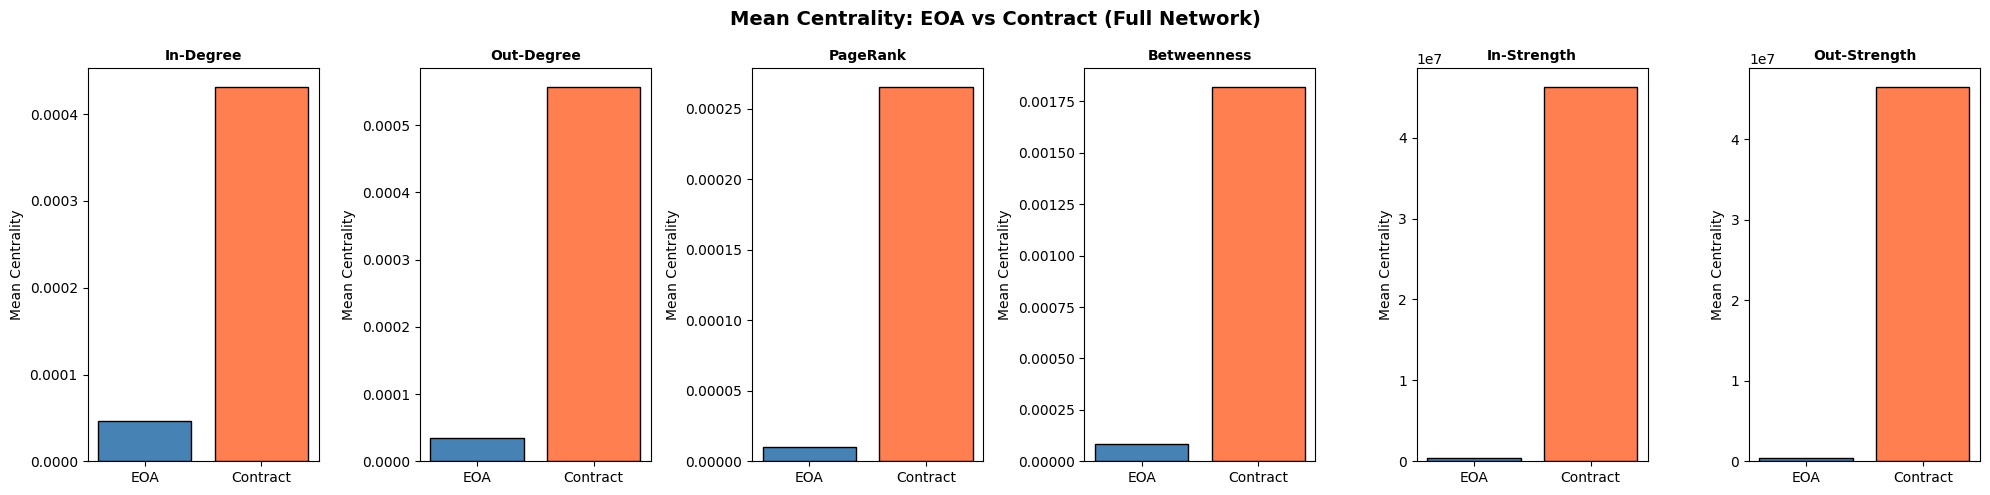

In [18]:
# Bar chart comparison
fig, axes = plt.subplots(1, len(cent_full), figsize=(20, 5))
for ax, (name, cent) in zip(axes, cent_full.items()):
    eoa_vals = [cent[n] for n in eoa_nodes if n in cent]
    sc_vals  = [cent[n] for n in contract_nodes if n in cent]
    ax.bar(['EOA', 'Contract'], [np.mean(eoa_vals), np.mean(sc_vals)],
           color=['steelblue', 'coral'], edgecolor='k')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Mean Centrality')
plt.suptitle('Mean Centrality: EOA vs Contract (Full Network)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Centrality Correlation Heatmap (Full Network)

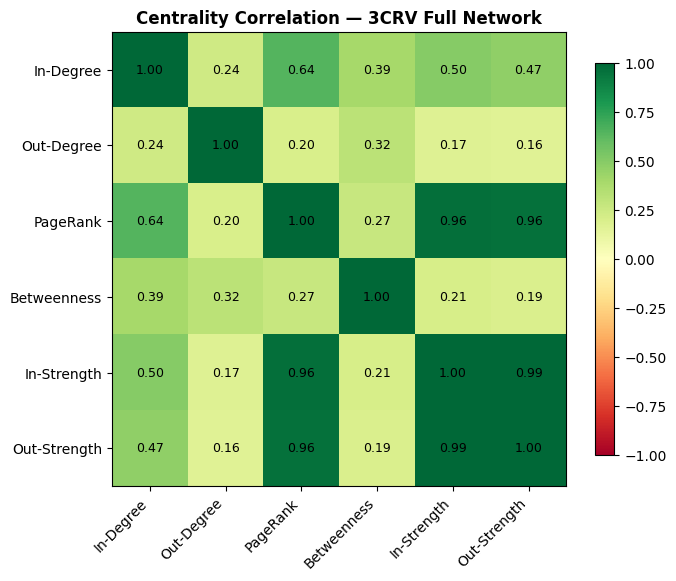

In [19]:
df_cent_full = pd.DataFrame(cent_full)
corr = df_cent_full.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Centrality Correlation — 3CRV Full Network', fontweight='bold')
plt.tight_layout()
plt.show()